# Modes Mobility Coupling near wall

## Libraries and dependencies

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import particles_mod.Icosphere as ico
import libMobility as lm
import pyvista as pv
pv.set_jupyter_backend('html')



   ██╗   ██╗██╗     ███╗   ███╗██████╗
   ██║   ██║██║     ████╗ ████║██╔══██╗
   ██║   ██║██║     ██╔████╔██║██████╔╝
   ╚██╗ ██╔╝██║     ██║╚██╔╝██║██╔═══╝
    ╚████╔╝ ███████╗██║ ╚═╝ ██║██║
     ╚═══╝  ╚══════╝╚═╝     ╚═╝╚═╝
    VIRTUAL   LAB    MODELING  PLATFORM




01/07/2025 14:46:38 - VLMP - INFO - Starting VLMP... 
01/07/2025 14:46:38 - VLMP - ERROR - No module named 'orthopoly' (__init__.py:187)
01/07/2025 14:46:38 - VLMP - ERROR - [Model] Error importing model type component CORONAVIRUS (__init__.py:188)
01/07/2025 14:46:38 - VLMP - ERROR - No module named 'Bio' (__init__.py:187)
01/07/2025 14:46:38 - VLMP - ERROR - [Model] Error importing model type component ENM (__init__.py:188)
01/07/2025 14:46:38 - VLMP - ERROR - No module named 'pyquaternion' (__init__.py:187)
01/07/2025 14:46:38 - VLMP - ERROR - [Model] Error importing model type component HELIX (__init__.py:188)
01/07/2025 14:46:38 - VLMP - ERROR - No module named 'Bio' (__init__.py:187)
01/07/2025 14:46:38 - VLMP - ERROR - [Model] Error importing model type component IDP (__init__.py:188)
01/07/2025 14:46:38 - VLMP - ERROR - No module named 'Bio' (__init__.py:187)
01/07/2025 14:46:38 - VLMP - ERROR - [Model] Error importing model type component KB (__init__.py:188)
01/07/2025 14:46:

## Functions

In [2]:
def create_solver(positions: np.ndarray, wallHeight: float = 0.0,
                  hydrodynamicRadius: float = 1.0, viscosity: float = 1/(6 * np.pi)):
    """
    Create a libmobility solver based on the NBodywall mobility.
    Args:
        positions: The positions of the particles.
        wallHeight: Height of the wall for the NBodywall model. Default is 0.0.
    Returns:
        solver: An instance of the solver for the specified model.
    """

    solver = lm.NBody("open", "open", "single_wall")
    solver.setParameters(wallHeight = wallHeight)

    solver.initialize(
        temperature=0.0,
        viscosity=viscosity,
        hydrodynamicRadius=hydrodynamicRadius,
    )

    solver.setPositions(positions)
    return solver

def plot_mode(positions : list, eigenmode: np.ndarray):
    """
    Plot the eigenmode of the Hessian matrix.
    :param positions: A list of tuples containing the x, y and z coordinates of each particle.
    :param eigenvectors: A numpy array containing the eigenmode data in (nparticles, 3) format.
    :param mode: The index of the eigenmode to plot.
    """

    new_positions = np.array(positions) + np.array(eigenmode)   # Scale the eigenmode for visualization

    mesh = pv.PolyData(new_positions)
    mesh = mesh.delaunay_3d()
    mesh['Eigenvector'] = eigenmode  # Add the eigenmode as a scalar field for coloring
    p = pv.Plotter()
    p.add_mesh(mesh, scalars='Eigenvector', show_scalar_bar=True, show_edges=False, cmap='coolwarm')
    p.add_arrows(np.array(positions), eigenmode / np.max(np.linalg.norm(eigenmode, axis=1))*3, color='blue', opacity=0.95
                 , name='Eigenvector Arrows')
    p.window_size = [300, 250]
    # add the coordinate triad bigger
    p.add_axes(interactive=True, line_width=5, labels_off=False, color='black')
    p.show()

## Creating icosphere and modes

In [3]:
num_particles = 200
density = 1/(np.pi * 1.05**2) # Closed package distribution
radius = np.sqrt(num_particles / (density * 4.0 * np.pi))

icosphere = ico.IcoSphere(radius=radius, density=density, Kpair=1.2, Kdi=1.2)


Creating icosphere with 200 particles and frequency division 4
Icosphere created with normalized positions and faces.
Number of particles: 162
Generating VLMP data for the icosphere.


01/07/2025 14:46:39 - VLMP - INFO - [VLMP] Starting VLMP 
01/07/2025 14:46:39 - VLMP - DEBUG - [VLMP] Processing "system" component ({'type': 'simulationName', 'parameters': {'simulationName': 'Icosphere'}}), type "simulationName" (VLMP.py:194)
01/07/2025 14:46:39 - VLMP - WARNING - [VLMP] (system) Component name not specified, using "simulationName". 
01/07/2025 14:46:39 - VLMP - DEBUG - [VLMP] (system) Component name "simulationName". (VLMP.py:200)
01/07/2025 14:46:39 - VLMP - DEBUG - [VLMP] (system) Component parameters "{'simulationName': 'Icosphere'}" (VLMP.py:207)
01/07/2025 14:46:39 - VLMP - DEBUG - [VLMP] Processing "system" component ({'type': 'simulationName', 'parameters': {'simulationName': 'Icosphere'}}), type "simulationName" (VLMP.py:194)
01/07/2025 14:46:39 - VLMP - WARNING - [VLMP] (system) Component name not specified, using "simulationName". 
01/07/2025 14:46:39 - VLMP - DEBUG - [VLMP] (system) Component name "simulationName". (VLMP.py:200)
01/07/2025 14:46:39 - VLMP

VLMP data generated.


In [4]:

icosphere.obtain_modes()





Preliminary simulation structure created
Read Hessian file /tmp/tmpyod7n36e/hessian.txt with shape (26244, 11)


[WARNING] UAMMD-structured Python wrapper is not compatible with UAMMD-structured self restarting mechanism
[MESSAGE] ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
[MESSAGE] ╻ ╻┏━┓┏┳┓┏┳┓╺┳┓
[MESSAGE] ┃ ┃┣━┫┃┃┃┃┃┃ ┃┃ Version: 2.5
[MESSAGE] ┗━┛╹ ╹╹ ╹╹ ╹╺┻┛
[MESSAGE] Compiled at: May 30 2025 09:48:24
[MESSAGE] Compiled in double precision mode
[MESSAGE] Computation started at Tue Jul  1 14:46:40 2025

[MESSAGE] [System] CUDA initialized
[MESSAGE] [System] Using device: NVIDIA GeForce RTX 3080 with id: 0
[MESSAGE] [System] Compute capability of the device: 8.6
[MESSAGE] ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ 
[MESSAGE] [ExtendedSystem] (system) Name: Icosphere
[MESSAGE] [ExtendedSystem] (system) Seed: 1751374000304989782
[MESSAGE] [GlobalDataBase] Fundamental not specified, using default fundamental, "Time"
[WARNING] [Time] No timeStep specified, using 0.0 as default.
[MESSAGE] [Basic] Loaded type A, mass: 1.000000, radius: 0.500000, charge: 0.000000
[MES

In [5]:

height = 2  # Wall height for the NBodywall model
solver = create_solver(icosphere.positions, wallHeight=-radius - height - 1.0)
coupling_matrix = icosphere.obtain_normal_coupled_mobility(solver)

In [6]:
N_matrix = coupling_matrix[6:,6:]
N_inverse = np.linalg.pinv(N_matrix)

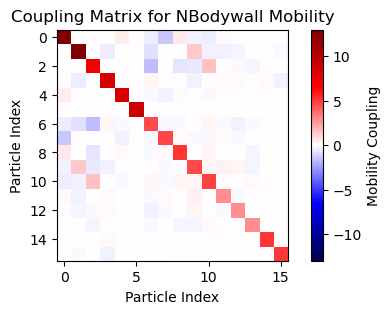

In [7]:
fig, ax = plt.subplots(figsize=(6, 3))
n = 16
ax.imshow(coupling_matrix[:n,:n])
ax.set_title("Coupling Matrix for NBodywall Mobility")
ax.set_xlabel("Particle Index")
ax.set_ylabel("Particle Index")
# add a colorbar from maximum and negative maximum as the range
max_value = np.max(np.abs(coupling_matrix[:n,:n]))
cbar = plt.colorbar(ax.imshow(coupling_matrix[:n,:n], aspect='equal', vmin=-max_value, vmax=max_value, cmap='seismic'), ax=ax)
cbar.set_label("Mobility Coupling")
plt.show()

In [ ]:
for mode in range(6, 12):
    plot_mode(icosphere.positions, icosphere.modes[:, mode].reshape(icosphere.nparticles, 3))

EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

In [14]:

deformation_modes = N_inverse @ coupling_matrix[6:,0]/icosphere.eigenvalues[6:]

In [15]:
plot_mode(icosphere.positions, (icosphere.modes[:, 6:] @ deformation_modes).reshape(icosphere.nparticles, 3))

EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

In [ ]:

# distance dependence of tt_eff_mobility

distances = np.linspace(0.1, 10, 100)
tt_eff_mobility = np.zeros_like(distances)
for i, distance in enumerate(distances):
    print(f"Calculating for distance {distance:.2f}")
    solver = create_solver(icosphere.positions, wallHeight=-radius - distance - 1.0)
    coupling_matrix = icosphere.obtain_normal_coupled_mobility(solver)
    N_matrix = coupling_matrix[6:,6:]
    N_inverse = np.linalg.pinv(N_matrix)

    tt_eff_mobility[i] = coupling_matrix[0,0] - coupling_matrix[0,6:] @ N_inverse @ coupling_matrix[6:,0]

plt.figure(figsize=(8, 4))
plt.plot(distances, tt_eff_mobility, label='Effective Translational Mobility')
plt.xlabel('Distance to Wall (scaled)')
plt.ylabel('Effective Translational Mobility')
plt.title('Distance Dependence of Effective Translational Mobility')
plt.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
plt.legend()
plt.grid()
plt.show()